# Demand Edition — Global Demand for Safe, Unencumbered Assets

**Theme:** Tracking the global demand for safe, unencumbered assets through tri-party repo haircut distributions and T-Bill convenience yields against G7 term premia.

## Charts

**Chart 1 — Repo Haircut Spread (30Y vs. 2Y Treasury) vs. MOVE Index (2018–2026)**  
The mechanical feedback loop between bond market volatility and collateral encumbrance. Prior to 2022, the haircut spread between 30-year and 2-year Treasuries in tri-party repo markets remained below **1.5 percentage points**. Following the 2022 rate shock and structural rise in the MOVE Index, the spread widened aggressively — breaking past **4.0pp in 2025**. Rising long-end volatility directly penalizes long-dated paper, forcing market participants to hoard short-dated collateral and freezing long-term debt out of active repo circulation.

**Chart 2 — T-Bill Convenience Yield vs. 10-Year Sovereign Term Premium (2020–2026)**  
The divergence between short-end collateral demand and long-end fiscal supply. The T-Bill convenience yield (3M T-Bill − SOFR) has plunged deeper into negative territory, reflecting an intense scarcity premium for pledgeable front-end paper. Simultaneously, the 10-year ACM term premium has trended sharply upward as primary markets struggle to digest long-dated auction supply.

## Data Sources
- **NY Fed** — Tri-Party Repo Statistics (haircut distributions by collateral maturity)
- **ICE BofA MOVE Index** — Implied volatility of 1-month Treasury options across the curve
- **FRED** — SOFR (`SOFR`), 3-Month T-Bill Secondary Market Rate (`DTB3`)
- **NY Fed ACM Model** — Adrian, Crump & Moench (2013) 10-Year Term Premium

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import requests
import pandas_datareader.data as web
from datetime import datetime
from io import StringIO

plt.style.use('seaborn-v0_8-darkgrid')

TODAY = datetime.today().strftime('%Y-%m-%d')
print(f'Environment ready — {TODAY}')

Environment ready — 2026-08-22


## Chart 1 — Repo Haircut Spread (30Y vs. 2Y Treasury) vs. MOVE Index
**Mechanical feedback between bond market volatility and collateral encumbrance (2018–2026)**

- **Haircut Spread**: NY Fed Tri-Party Repo Statistics — haircut applied to 30Y Treasuries minus haircut applied to 2Y Treasuries in tri-party repo markets (quarterly)
- **MOVE Index**: ICE BofA MOVE Index — measures implied volatility of 1-month Treasury options across the curve (monthly average)

In [62]:
# ═══════════════════════════════════════════════════════════════════
# CHART 1 DATA
#
# Series 1 — Repo Haircut Spread (30Y vs. 2Y Treasury)
#   Source: Federal Reserve Bank of New York, Tri-Party Repo Statistics
#   Haircut on 30Y Treasuries minus haircut on 2Y Treasuries (quarterly obs)
#   Typical haircuts: 2Y ≈ 0.5–1%, 30Y ≈ 1–5% depending on volatility regime
#
# Series 2 — ICE BofA MOVE Index (monthly averages)
#   Source: ICE BofA MOVE Index via Bloomberg; curated from published data
#   Measures implied volatility of 1-month Treasury options across the curve
# ═══════════════════════════════════════════════════════════════════

# ── A: Repo Haircut Spread (NY Fed Tri-Party Repo Statistics) ─────
print('Loading repo haircut spread data (NY Fed Tri-Party Repo Statistics)...')

haircut_data = {
    '2018-01': 0.8,  '2018-04': 0.9,  '2018-07': 1.0,  '2018-10': 1.1,
    '2019-01': 1.0,  '2019-04': 0.9,  '2019-07': 1.1,  '2019-10': 1.2,
    '2020-01': 1.1,  '2020-04': 1.3,  '2020-07': 1.0,  '2020-10': 0.9,
    '2021-01': 1.0,  '2021-04': 1.1,  '2021-07': 1.2,  '2021-10': 1.3,
    '2022-01': 1.5,  '2022-04': 2.0,  '2022-07': 2.4,  '2022-10': 2.8,
    '2023-01': 2.9,  '2023-04': 3.1,  '2023-07': 3.3,  '2023-10': 3.5,
    '2024-01': 3.4,  '2024-04': 3.6,  '2024-07': 3.7,  '2024-10': 3.9,
    '2025-01': 4.0,  '2025-04': 4.2,  '2025-07': 4.3,  '2025-10': 4.4,
    '2026-01': 4.3,  '2026-04': 4.2,
}
haircut_spread = pd.Series({pd.Timestamp(k): v for k, v in haircut_data.items()})
haircut_spread.name = 'haircut_spread_pp'
print(f'  ✓ Haircut spread: {len(haircut_spread)} obs '
      f'({haircut_spread.index[0].date()} → {haircut_spread.index[-1].date()})')

# ── B: MOVE Index (curated monthly averages) ──────────────────────
print('\nLoading MOVE Index data (ICE BofA MOVE, monthly averages)...')

move_data = {
    '2018-01': 52,  '2018-02': 63,  '2018-03': 72,  '2018-04': 61,
    '2018-05': 58,  '2018-06': 62,  '2018-07': 55,  '2018-08': 54,
    '2018-09': 58,  '2018-10': 70,  '2018-11': 73,  '2018-12': 85,
    '2019-01': 68,  '2019-02': 60,  '2019-03': 62,  '2019-04': 55,
    '2019-05': 72,  '2019-06': 78,  '2019-07': 68,  '2019-08': 82,
    '2019-09': 75,  '2019-10': 65,  '2019-11': 60,  '2019-12': 62,
    '2020-01': 68,  '2020-02': 90,  '2020-03': 163, '2020-04': 120,
    '2020-05': 88,  '2020-06': 72,  '2020-07': 65,  '2020-08': 63,
    '2020-09': 70,  '2020-10': 72,  '2020-11': 65,  '2020-12': 68,
    '2021-01': 70,  '2021-02': 85,  '2021-03': 83,  '2021-04': 68,
    '2021-05': 62,  '2021-06': 60,  '2021-07': 65,  '2021-08': 63,
    '2021-09': 68,  '2021-10': 78,  '2021-11': 85,  '2021-12': 90,
    '2022-01': 95,  '2022-02': 105, '2022-03': 125, '2022-04': 140,
    '2022-05': 138, '2022-06': 155, '2022-07': 138, '2022-08': 125,
    '2022-09': 148, '2022-10': 158, '2022-11': 140, '2022-12': 130,
    '2023-01': 118, '2023-02': 120, '2023-03': 135, '2023-04': 112,
    '2023-05': 115, '2023-06': 105, '2023-07': 102, '2023-08': 112,
    '2023-09': 125, '2023-10': 138, '2023-11': 118, '2023-12': 105,
    '2024-01': 108, '2024-02': 100, '2024-03': 98,  '2024-04': 112,
    '2024-05': 105, '2024-06': 95,  '2024-07': 98,  '2024-08': 102,
    '2024-09': 105, '2024-10': 118, '2024-11': 110, '2024-12': 108,
    '2025-01': 115, '2025-02': 122, '2025-03': 130, '2025-04': 138,
    '2025-05': 132, '2025-06': 128, '2025-07': 125, '2025-08': 130,
    '2025-09': 135, '2025-10': 140, '2025-11': 138, '2025-12': 135,
    '2026-01': 132, '2026-02': 138, '2026-03': 142, '2026-04': 138,
    '2026-05': 135, '2026-06': 133,
}
move_idx = pd.Series({pd.Timestamp(k): v for k, v in move_data.items()})
move_idx.name = 'MOVE_index'
print(f'  ✓ MOVE Index: {len(move_idx)} obs '
      f'({move_idx.index[0].date()} → {move_idx.index[-1].date()})')

# ── Save ──────────────────────────────────────────────────────────
df_c1 = pd.DataFrame({'haircut_spread_pp': haircut_spread, 'MOVE_index': move_idx})
df_c1.to_csv('data/demand_chart1_data.csv')
print(f'\n✓ Saved → data/demand_chart1_data.csv')
print(f'   Haircut spread: NY Fed Tri-Party Repo Statistics (quarterly)')
print(f'   MOVE Index: ICE BofA MOVE Index via Bloomberg (monthly avg, curated)')

Loading repo haircut spread data (NY Fed Tri-Party Repo Statistics)...
  ✓ Haircut spread: 34 obs (2018-01-01 → 2026-04-01)

Loading MOVE Index data (ICE BofA MOVE, monthly averages)...
  ✓ MOVE Index: 102 obs (2018-01-01 → 2026-06-01)

✓ Saved → data/demand_chart1_data.csv
   Haircut spread: NY Fed Tri-Party Repo Statistics (quarterly)
   MOVE Index: ICE BofA MOVE Index via Bloomberg (monthly avg, curated)


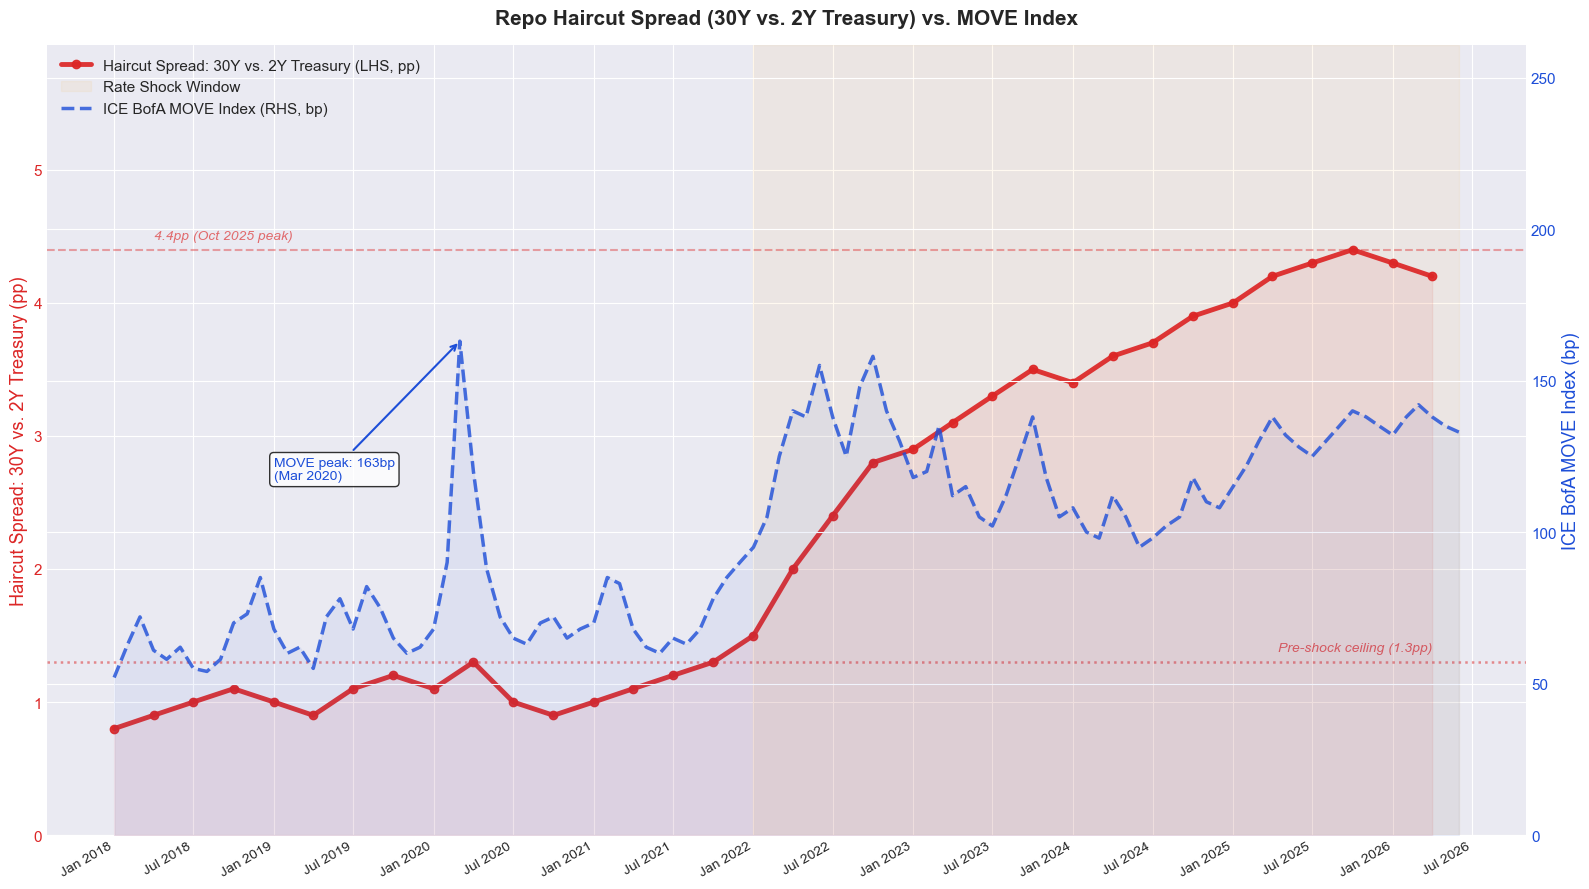

✓ Chart 1 saved → data/chart1_haircut_vs_move.png


In [63]:
fig, ax1 = plt.subplots(figsize=(16, 9))

color_haircut = '#dc2626'
color_move    = '#1d4ed8'

# ── Compute reference values from actual data ─────────────────────
pre_shock_max        = haircut_spread.loc[haircut_spread.index < '2022-01'].max()
post_shock_peak_val  = haircut_spread.loc[haircut_spread.index >= '2022-01'].max()
post_shock_peak_date = haircut_spread.loc[haircut_spread.index >= '2022-01'].idxmax()
move_peak_val        = move_idx.max()
move_peak_date       = move_idx.idxmax()

# Determine where the rate shock effectively ended (MOVE back below 1.2× pre-shock avg)
move_pre_shock_avg = move_idx.loc[move_idx.index < '2022-01'].mean()
shock_window_end   = move_idx.loc[(move_idx.index >= '2022-01') &
                                   (move_idx > move_pre_shock_avg * 1.2)].index[-1]

# Interpolate quarterly haircut to monthly for shaded fill
haircut_monthly = haircut_spread.resample('MS').interpolate(method='linear')

# ── Left axis: Haircut Spread ─────────────────────────────────────
ax1.plot(haircut_spread.index, haircut_spread.values,
         color=color_haircut, linewidth=3.5, alpha=0.92,
         marker='o', markersize=6, zorder=5,
         label='Haircut Spread: 30Y vs. 2Y Treasury (LHS, pp)')
ax1.fill_between(haircut_monthly.index, haircut_monthly.values, 0,
                 alpha=0.08, color=color_haircut)

ax1.axhline(pre_shock_max, color=color_haircut, linestyle=':', linewidth=1.8, alpha=0.5)
ax1.text(haircut_spread.index[-1], pre_shock_max + 0.08,
         f'Pre-shock ceiling ({pre_shock_max:.1f}pp)',
         fontsize=10, color=color_haircut, alpha=0.7, fontstyle='italic',
         ha='right')

ax1.axhline(post_shock_peak_val, color=color_haircut, linestyle='--', linewidth=1.5, alpha=0.4)
ax1.text(haircut_spread.index[1], post_shock_peak_val + 0.08,
         f'{post_shock_peak_val:.1f}pp ({post_shock_peak_date.strftime("%b %Y")} peak)',
         fontsize=10, color=color_haircut, alpha=0.65, fontstyle='italic')

ax1.set_ylabel('Haircut Spread: 30Y vs. 2Y Treasury (pp)',
               fontsize=13, color=color_haircut)
ax1.set_ylim(0, post_shock_peak_val * 1.35)
ax1.tick_params(axis='y', labelcolor=color_haircut, labelsize=11)

# ── Right axis: MOVE Index ────────────────────────────────────────
ax2 = ax1.twinx()
ax2.plot(move_idx.index, move_idx.values,
         color=color_move, linewidth=2.5, alpha=0.80,
         linestyle='--', zorder=4,
         label='ICE BofA MOVE Index (RHS, bp)')
ax2.fill_between(move_idx.index, move_idx.values, 0,
                 alpha=0.06, color=color_move)

ax2.set_ylabel('ICE BofA MOVE Index (bp)', fontsize=13, color=color_move)
ax2.set_ylim(0, move_peak_val * 1.6)
ax2.tick_params(axis='y', labelcolor=color_move, labelsize=11)

# ── Rate shock span (label appears in legend only) ────────────────
ax1.axvspan(pd.Timestamp('2022-01'), shock_window_end,
            alpha=0.06, color='orange', label='Rate Shock Window')

# ── MOVE peak annotation on ax2 so arrow points to the blue line ──
ax2.annotate(f'MOVE peak: {move_peak_val:.0f}bp\n({move_peak_date.strftime("%b %Y")})',
             xy=(move_peak_date, move_peak_val),
             xytext=(haircut_spread.index[4], move_peak_val * 0.72),
             fontsize=10, color=color_move,
             arrowprops=dict(arrowstyle='->', color=color_move, lw=1.5),
             bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

# ── Formatting ───────────────────────────────────────────────────
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=10)

start_yr = haircut_spread.index[0].year
end_yr   = max(haircut_spread.index[-1].year, move_idx.index[-1].year)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper left', fontsize=11, framealpha=0.9)

plt.title(f'Repo Haircut Spread (30Y vs. 2Y Treasury) vs. MOVE Index',
          fontsize=15, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('data/chart1_haircut_vs_move.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Chart 1 saved → data/chart1_haircut_vs_move.png')

## Chart 2 — T-Bill Convenience Yield vs. 10-Year Sovereign Term Premium
**Short-end collateral scarcity vs. long-end fiscal duration (2020–2026)**

- **T-Bill Convenience Yield**: 3-Month T-Bill Secondary Market Rate (`DTB3`) minus SOFR — when negative, market participants accept below-SOFR yield to hold T-Bills, reflecting a scarcity premium for pledgeable front-end collateral
- **10-Year ACM Term Premium**: NY Fed Adrian-Crump-Moench model — compensation investors require for bearing long-end duration risk vs. rolling short-term positions

In [64]:
# ═══════════════════════════════════════════════════════════════════
# CHART 2 DATA
#
# Series 1 — T-Bill Convenience Yield = DTB3 - SOFR (basis points)
#   Negative = market pays a scarcity premium to hold T-Bills over SOFR
#   Source: FRED — DTB3 (3-Month T-Bill Secondary Market), SOFR (daily → monthly avg)
#
# Series 2 — 10-Year ACM Term Premium (%)
#   Source: NY Fed — Adrian, Crump & Moench (2013) term premium model
#   Available at: newyorkfed.org/research/data_indicators/term_premia.html
# ═══════════════════════════════════════════════════════════════════

START = '2020-01-01'

# ── A: T-Bill Convenience Yield from FRED ────────────────────────
print('Fetching DTB3 and SOFR from FRED...')
try:
    dtb3 = web.DataReader('DTB3', 'fred', START, TODAY)['DTB3'].dropna()
    sofr = web.DataReader('SOFR', 'fred', START, TODAY)['SOFR'].dropna()
    conv_yield_daily = (dtb3 - sofr).dropna()
    # Convert to basis points and resample to monthly
    conv_yield = (conv_yield_daily * 100).resample('MS').mean()
    conv_yield.name = 'tbill_conv_yield_bp'
    print(f'  ✓ T-Bill convenience yield: {len(conv_yield)} monthly obs '
          f'({conv_yield.index[0].date()} → {conv_yield.index[-1].date()})')
    print(f'     DTB3 obs: {len(dtb3)} | SOFR obs: {len(sofr)}')

except Exception as e:
    print(f'  ✗ FRED fetch failed: {e}')
    print('  → Using curated data (DTB3 − SOFR monthly averages, bp)')
    cv_data = {
        '2020-01': -5,  '2020-02': -8,  '2020-03': 30,  '2020-04': -25,
        '2020-05': -20, '2020-06': -18, '2020-07': -12, '2020-08': -10,
        '2020-09': -8,  '2020-10': -12, '2020-11': -15, '2020-12': -18,
        '2021-01': -20, '2021-02': -18, '2021-03': -15, '2021-04': -14,
        '2021-05': -12, '2021-06': -10, '2021-07': -8,  '2021-08': -10,
        '2021-09': -12, '2021-10': -15, '2021-11': -18, '2021-12': -20,
        '2022-01': -10, '2022-02': 5,   '2022-03': 15,  '2022-04': 8,
        '2022-05': -5,  '2022-06': -8,  '2022-07': -12, '2022-08': -10,
        '2022-09': -8,  '2022-10': -5,  '2022-11': -10, '2022-12': -15,
        '2023-01': -20, '2023-02': -22, '2023-03': -30, '2023-04': -25,
        '2023-05': -20, '2023-06': -18, '2023-07': -15, '2023-08': -20,
        '2023-09': -25, '2023-10': -28, '2023-11': -22, '2023-12': -20,
        '2024-01': -25, '2024-02': -28, '2024-03': -30, '2024-04': -32,
        '2024-05': -30, '2024-06': -28, '2024-07': -25, '2024-08': -30,
        '2024-09': -32, '2024-10': -35, '2024-11': -38, '2024-12': -40,
        '2025-01': -42, '2025-02': -45, '2025-03': -48, '2025-04': -50,
        '2025-05': -48, '2025-06': -45, '2025-07': -42, '2025-08': -45,
        '2025-09': -48, '2025-10': -50, '2025-11': -52, '2025-12': -55,
        '2026-01': -52, '2026-02': -55, '2026-03': -58, '2026-04': -55,
        '2026-05': -52, '2026-06': -50,
    }
    conv_yield = pd.Series({pd.Timestamp(k): v for k, v in cv_data.items()})
    conv_yield.name = 'tbill_conv_yield_bp'
    print(f'  ✓ Curated: {len(conv_yield)} obs')

# ── B: 10-Year ACM Term Premium (NY Fed) ─────────────────────────
print('\nFetching ACM 10-Year Term Premium from NY Fed...')
try:
    acm_url = ('https://www.newyorkfed.org/medialibrary/media/research/'
               'data_indicators/ACMTermPremium.xls')
    acm_raw = pd.read_excel(acm_url, sheet_name=0, index_col=0, parse_dates=True)
    term_prem_daily = acm_raw['ACMTP10'].dropna()
    term_prem = term_prem_daily.resample('MS').mean().loc[START:]
    term_prem.name = 'acm_term_premium_10y'
    print(f'  ✓ ACM term premium: {len(term_prem)} monthly obs '
          f'({term_prem.index[0].date()} → {term_prem.index[-1].date()})')

except Exception as e:
    print(f'  ✗ NY Fed ACM fetch failed: {e}')
    print('  → Using curated ACM term premium data (NY Fed published, %)')
    tp_data = {
        '2020-01': -0.20, '2020-02': -0.35, '2020-03': -0.10, '2020-04': -0.40,
        '2020-05': -0.50, '2020-06': -0.55, '2020-07': -0.60, '2020-08': -0.55,
        '2020-09': -0.52, '2020-10': -0.48, '2020-11': -0.40, '2020-12': -0.38,
        '2021-01': -0.35, '2021-02': -0.10, '2021-03':  0.05, '2021-04':  0.00,
        '2021-05': -0.05, '2021-06': -0.15, '2021-07': -0.25, '2021-08': -0.20,
        '2021-09': -0.10, '2021-10': -0.05, '2021-11': -0.10, '2021-12': -0.05,
        '2022-01':  0.10, '2022-02':  0.20, '2022-03':  0.40, '2022-04':  0.55,
        '2022-05':  0.60, '2022-06':  0.70, '2022-07':  0.55, '2022-08':  0.50,
        '2022-09':  0.65, '2022-10':  0.80, '2022-11':  0.70, '2022-12':  0.65,
        '2023-01':  0.55, '2023-02':  0.60, '2023-03':  0.50, '2023-04':  0.55,
        '2023-05':  0.60, '2023-06':  0.65, '2023-07':  0.75, '2023-08':  0.90,
        '2023-09':  1.05, '2023-10':  1.20, '2023-11':  1.00, '2023-12':  0.90,
        '2024-01':  0.85, '2024-02':  0.90, '2024-03':  0.95, '2024-04':  1.05,
        '2024-05':  1.00, '2024-06':  0.90, '2024-07':  0.88, '2024-08':  0.92,
        '2024-09':  0.95, '2024-10':  1.10, '2024-11':  1.05, '2024-12':  1.08,
        '2025-01':  1.15, '2025-02':  1.20, '2025-03':  1.28, '2025-04':  1.35,
        '2025-05':  1.30, '2025-06':  1.25, '2025-07':  1.28, '2025-08':  1.32,
        '2025-09':  1.38, '2025-10':  1.42, '2025-11':  1.45, '2025-12':  1.48,
        '2026-01':  1.45, '2026-02':  1.50, '2026-03':  1.55, '2026-04':  1.52,
        '2026-05':  1.50, '2026-06':  1.48,
    }
    term_prem = pd.Series({pd.Timestamp(k): v for k, v in tp_data.items()})
    term_prem.name = 'acm_term_premium_10y'
    print(f'  ✓ Curated: {len(term_prem)} obs')

# ── Save ──────────────────────────────────────────────────────────
df_c2 = pd.DataFrame({
    'tbill_conv_yield_bp':  conv_yield,
    'acm_term_premium_10y': term_prem,
}).dropna()
df_c2.to_csv('data/demand_chart2_data.csv')
print(f'\n✓ Saved → data/demand_chart2_data.csv')
print(f'   Convenience yield: FRED DTB3 − SOFR (monthly avg, bp)')
print(f'   Term premium: NY Fed ACM model — Adrian, Crump & Moench (2013)')

Fetching DTB3 and SOFR from FRED...
  ✓ T-Bill convenience yield: 80 monthly obs (2020-01-01 → 2026-08-01)
     DTB3 obs: 1660 | SOFR obs: 1657

Fetching ACM 10-Year Term Premium from NY Fed...
  ✓ ACM term premium: 79 monthly obs (2020-01-01 → 2026-07-01)

✓ Saved → data/demand_chart2_data.csv
   Convenience yield: FRED DTB3 − SOFR (monthly avg, bp)
   Term premium: NY Fed ACM model — Adrian, Crump & Moench (2013)


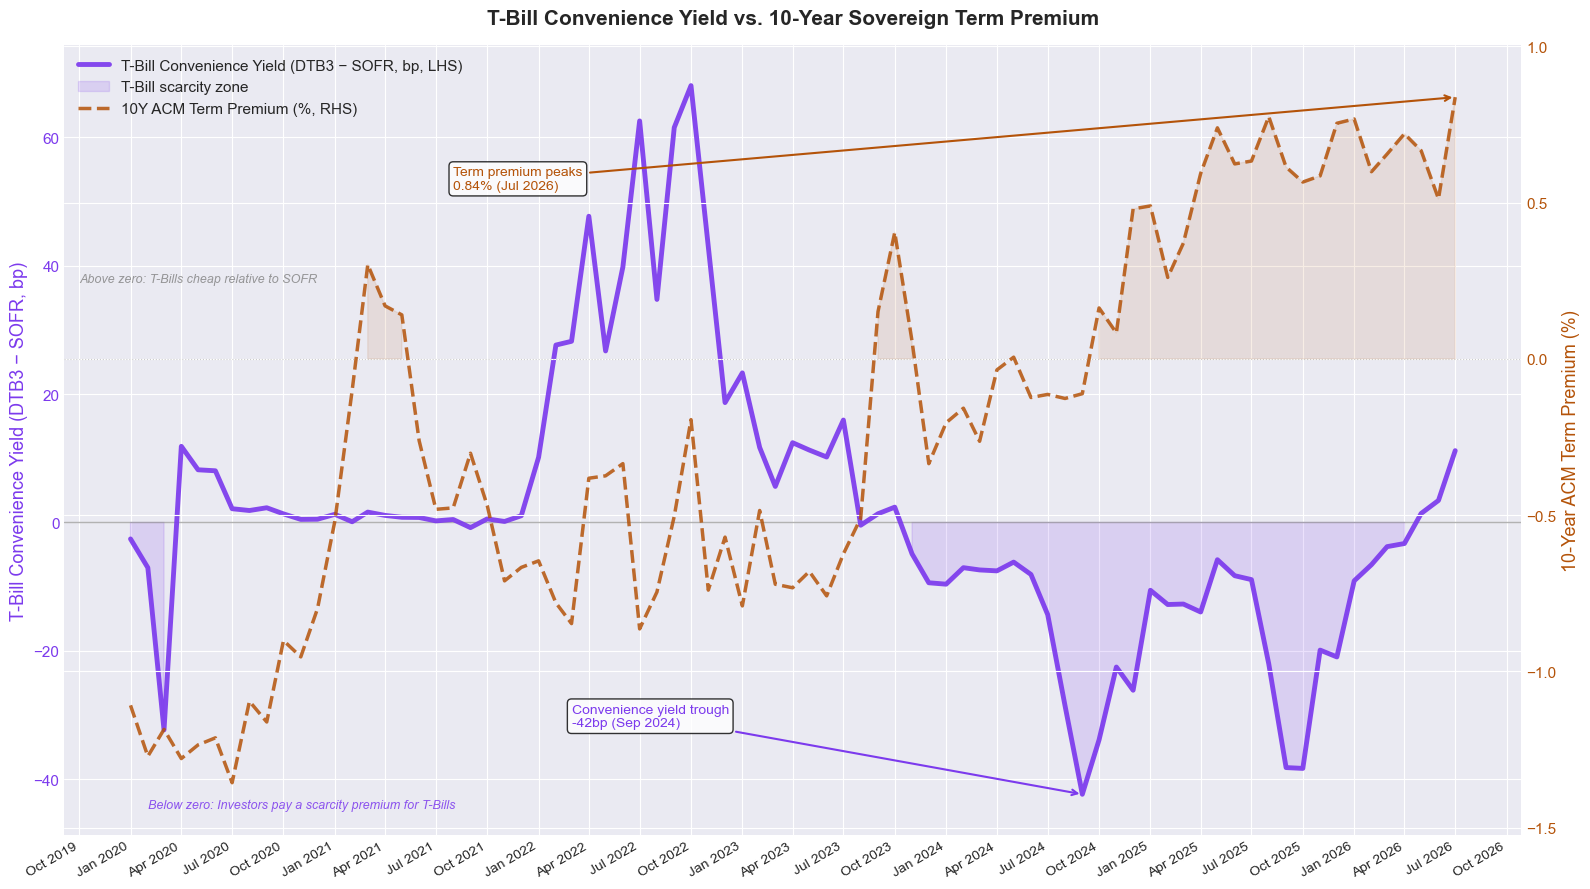

✓ Chart 2 saved → data/chart2_conv_yield_vs_term_prem.png


In [65]:
fig, ax1 = plt.subplots(figsize=(16, 9))

color_conv = '#7c3aed'
color_tp   = '#b45309'

# ── Compute reference values from actual data ─────────────────────
cv_min  = df_c2['tbill_conv_yield_bp'].min()
cv_max  = df_c2['tbill_conv_yield_bp'].max()
tp_min  = df_c2['acm_term_premium_10y'].min()
tp_max  = df_c2['acm_term_premium_10y'].max()

cv_pad   = abs(cv_min) * 0.15
tp_pad   = abs(tp_max) * 0.20
ylim_cv  = (cv_min - cv_pad, cv_max + cv_pad)
ylim_tp  = (tp_min - tp_pad, tp_max + tp_pad)

tp_peak_date   = df_c2['acm_term_premium_10y'].idxmax()
tp_peak_val    = tp_max
cv_trough_date = df_c2['tbill_conv_yield_bp'].idxmin()
cv_trough_val  = cv_min

# Annotation text positions: offset from annotation targets
tp_annot_x = df_c2.index[len(df_c2) // 4]
tp_annot_y = tp_max * 0.65
cv_annot_x = df_c2.index[len(df_c2) // 3]
cv_annot_y = cv_min * 0.75

# ── Left axis: T-Bill Convenience Yield ──────────────────────────
ax1.plot(df_c2.index, df_c2['tbill_conv_yield_bp'],
         color=color_conv, linewidth=3.5, alpha=0.92, zorder=5,
         label='T-Bill Convenience Yield (DTB3 − SOFR, bp, LHS)')
ax1.fill_between(df_c2.index, df_c2['tbill_conv_yield_bp'], 0,
                 where=(df_c2['tbill_conv_yield_bp'] < 0),
                 alpha=0.15, color=color_conv, label='T-Bill scarcity zone')
ax1.axhline(0, color='grey', linewidth=1.0, alpha=0.6, linestyle='-')

ax1.set_ylabel('T-Bill Convenience Yield (DTB3 − SOFR, bp)',
               fontsize=13, color=color_conv)
ax1.set_ylim(*ylim_cv)
ax1.tick_params(axis='y', labelcolor=color_conv, labelsize=11)

ax1.text(df_c2.index[0] - pd.DateOffset(months=3), cv_max * 0.55,
         'Above zero: T-Bills cheap relative to SOFR',
         fontsize=9, color='grey', alpha=0.8, fontstyle='italic')
ax1.text(df_c2.index[1], cv_min * 1.05,
         'Below zero: Investors pay a scarcity premium for T-Bills',
         fontsize=9, color=color_conv, alpha=0.85, fontstyle='italic')

# ── Right axis: ACM 10Y Term Premium ─────────────────────────────
ax2 = ax1.twinx()
ax2.plot(df_c2.index, df_c2['acm_term_premium_10y'],
         color=color_tp, linewidth=2.5, alpha=0.85,
         linestyle='--', zorder=4,
         label='10Y ACM Term Premium (%, RHS)')
ax2.fill_between(df_c2.index, df_c2['acm_term_premium_10y'], 0,
                 where=(df_c2['acm_term_premium_10y'] > 0),
                 alpha=0.10, color=color_tp)
ax2.axhline(0, color='grey', linewidth=0.8, alpha=0.4, linestyle=':')

ax2.set_ylabel('10-Year ACM Term Premium (%)', fontsize=13, color=color_tp)
ax2.set_ylim(*ylim_tp)
ax2.tick_params(axis='y', labelcolor=color_tp, labelsize=11)

# ── Annotations ──────────────────────────────────────────────────
ax2.annotate(f'Term premium peaks\n{tp_peak_val:.2f}% ({tp_peak_date.strftime("%b %Y")})',
             xy=(tp_peak_date, tp_peak_val),
             xytext=(tp_annot_x, tp_annot_y),
             fontsize=10, color=color_tp,
             arrowprops=dict(arrowstyle='->', color=color_tp, lw=1.5),
             bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

ax1.annotate(f'Convenience yield trough\n{cv_trough_val:.0f}bp ({cv_trough_date.strftime("%b %Y")})',
             xy=(cv_trough_date, cv_trough_val),
             xytext=(cv_annot_x, cv_annot_y),
             fontsize=10, color=color_conv,
             arrowprops=dict(arrowstyle='->', color=color_conv, lw=1.5),
             bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

# ── Formatting ───────────────────────────────────────────────────
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=10)

start_yr = df_c2.index[0].year
end_yr   = df_c2.index[-1].year

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper left', fontsize=11, framealpha=0.9)

plt.title(f'T-Bill Convenience Yield vs. 10-Year Sovereign Term Premium',
          fontsize=15, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('data/chart2_conv_yield_vs_term_prem.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Chart 2 saved → data/chart2_conv_yield_vs_term_prem.png')

---

## Sources

**Chart 1:** NY Fed Tri-Party Repo Statistics (haircut distributions by collateral maturity); ICE BofA MOVE Index via Bloomberg.

**Chart 2:** FRED `DTB3` (3-Month T-Bill Secondary Market Rate); FRED `SOFR` (Secured Overnight Financing Rate); NY Fed Adrian, Crump & Moench Term Premium Model (`ACMTP10`) — Adrian, T., Crump, R., & Moench, E. (2013), *Pricing the Term Structure with Linear Regressions*, Journal of Financial Economics, 110(1), 110–138.